# Preprocessing - Obianuju Nonyerem Anuma

DDPM Samples:


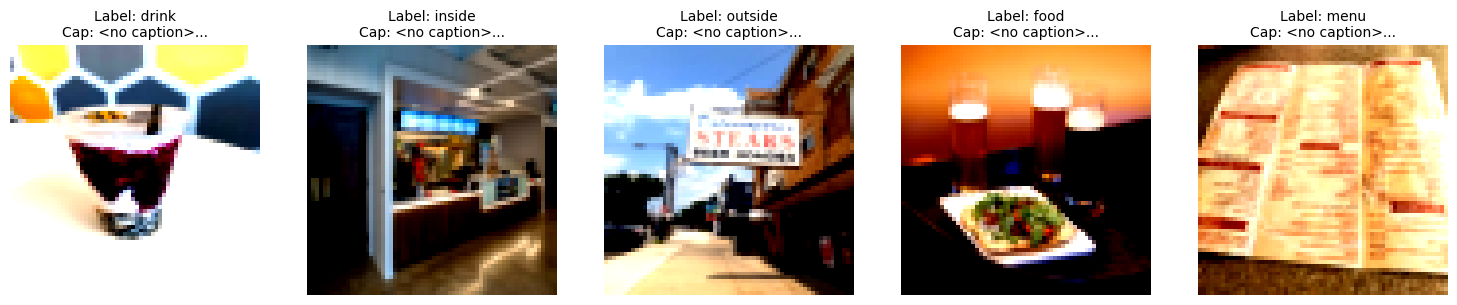

DDIM Samples:


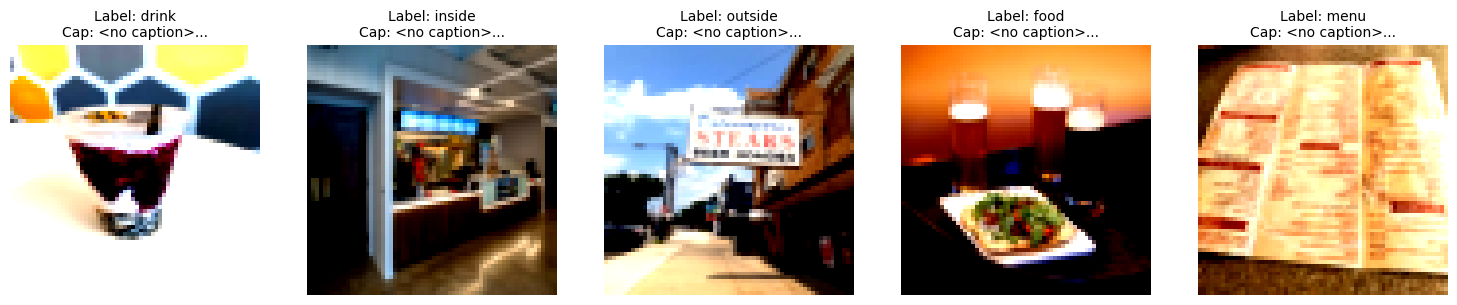

Latent Diffusion Samples:


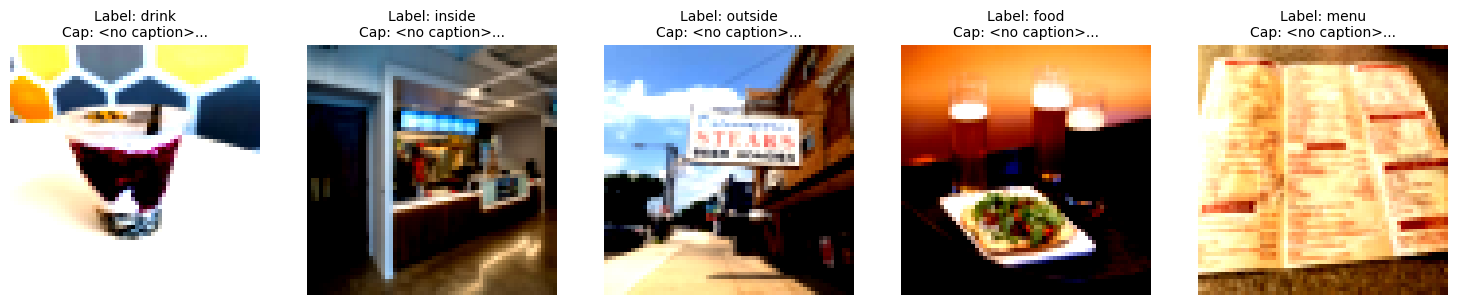

Text-to-Image Diffusion Samples:


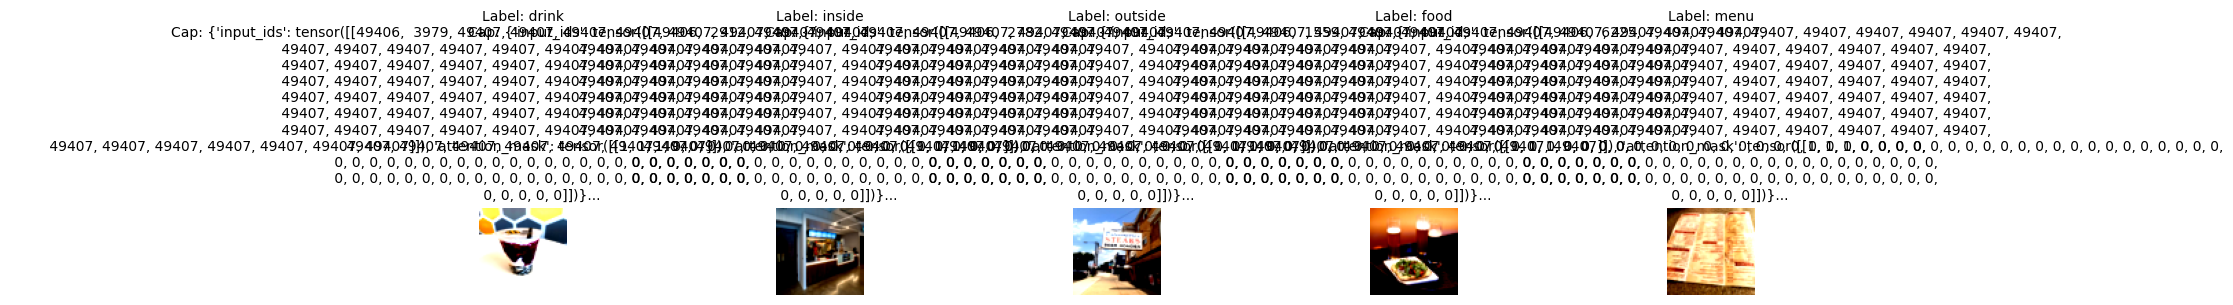

In [ ]:
# -------------------------------
# Imports and Config
# -------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Load Data
# -------------------------------
metadata_path = "./Yelp Photos/photos.json"
df = pd.read_json(metadata_path, lines=True)

# -------------------------------
# Data Split
# -------------------------------
def split_json_df(df, test_size=0.2, random_state=42):
    """Split DataFrame into stratified train and test sets"""
    return train_test_split(df, test_size=test_size, stratify=df["label"], random_state=random_state)

train_df, test_df = split_json_df(df)

# -------------------------------
# Image Transforms
# -------------------------------
def get_transforms(augment=False):
    """Return torchvision transforms with optional augmentation"""
    transform_list = [transforms.Resize((64, 64))]
    if augment:
        transform_list.append(transforms.RandomHorizontalFlip())
    transform_list += [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]
    return transforms.Compose(transform_list)

# -------------------------------
# Dataset Classes
# -------------------------------
class YelpJSONDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None):
        """
        Dataset for Yelp image metadata

        Args:
            dataframe (DataFrame): Image metadata
            image_dir (str): Folder path to image files
            transform (callable): Default image transform
            menu_transform (callable): Transform applied only to 'menu' images
        """
        self.data = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.menu_transform = menu_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{item['photo_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        label = item['label']

        # Apply menu-specific transform
        if label == 'menu' and self.menu_transform:
            image = self.menu_transform(image)
        elif self.transform:
            image = self.transform(image)

        return image, label, ""

# -------------------------------
# Preprocessing Pipelines
# -------------------------------
def preprocess_ddpm(train_df, test_df, image_dir):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpJSONDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform),
        YelpJSONDataset(test_df, image_dir, transform=test_transform)
    )

def preprocess_ddim(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

def preprocess_latent_diffusion(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

class YelpTextToImageDataset(YelpJSONDataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None, tokenizer=None):
        """
        Extension of YelpJSONDataset for text-to-image models

        Args:
            tokenizer: CLIPTokenizer for encoding captions
        """
        super().__init__(dataframe, image_dir, transform, menu_transform)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        image, label, _ = super().__getitem__(idx)
        caption = label  # Using label as caption for now
        if self.tokenizer:
            caption = self.tokenizer(caption, padding="max_length", truncation=True, return_tensors="pt")
        return image, label, caption

def preprocess_text_to_image(train_df, test_df, image_dir, tokenizer):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpTextToImageDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform, tokenizer=tokenizer),
        YelpTextToImageDataset(test_df, image_dir, transform=test_transform, tokenizer=tokenizer)
    )

# -------------------------------
# Visualization Utility
# -------------------------------
def show_sample_images(dataset, num_samples=5, show_caption=True):
    """
    Plots sample images from the dataset with their labels and captions.

    Args:
        dataset (Dataset): Dataset object
        num_samples (int): Number of images to preview
        show_caption (bool): Show caption text under each image
    """
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image, label, caption = dataset[i]
        image = image.numpy().transpose(1, 2, 0)
        image = image + 0.5
        image = np.clip(image, 0, 1)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.axis('off')

        if isinstance(caption, dict):
            try:
                input_ids = caption["input_ids"][0]
                caption_text = tokenizer.decode(input_ids, skip_special_tokens=True)
            except Exception:
                caption_text = "<tokenized>"
        else:
            caption_text = caption if caption else "<no caption>"

        title = f"Label: {label}"
        if show_caption:
            title += f"\nCap: {caption_text[:30]}..."
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Run Preprocessors
# -------------------------------
image_dir = "./Yelp Photos/photos"
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

train_ddpm, test_ddpm = preprocess_ddpm(train_df, test_df, image_dir)
train_ddim, test_ddim = preprocess_ddim(train_df, test_df, image_dir)
train_ldm, test_ldm = preprocess_latent_diffusion(train_df, test_df, image_dir)
train_glide, test_glide = preprocess_text_to_image(train_df, test_df, image_dir, tokenizer)

# -------------------------------
# Preview Samples
# -------------------------------
print("DDPM Samples:")
show_sample_images(train_ddpm)

print("DDIM Samples:")
show_sample_images(train_ddim)

print("Latent Diffusion Samples:")
show_sample_images(train_ldm)

print("Text-to-Image Diffusion Samples:")
show_sample_images(train_glide, show_caption=True)

# -------------------------------
# Save Datasets
# -------------------------------

# Exporting the datasets for later use:
# Option 1: Saving as Pytorch Objects
torch.save(train_ddpm, "train_ddpm.pt")
torch.save(test_ddpm, "test_ddpm.pt")

torch.save(train_ddim, "train_ddim.pt")
torch.save(test_ddim, "test_ddim.pt")

torch.save(train_ldm, "train_ldm.pt")
torch.save(test_ldm, "test_ldm.pt")

torch.save(train_glide, "train_glide.pt")
torch.save(test_glide, "test_glide.pt")

# Option 2: Saving the test and train csv files (underlying data)
train_df.to_csv("train_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

In [ ]:
# Note to colleagues:
# If using PyTorch, get the dataset objects directly using torch.load("train_ddpm.pt") for example.
# If using the underlying data,run the preprocessing step for your model. This provides more flexibility.

#### LLM Used: ChatGPT
- First prompt: 
**Read through questions step by step**
Consider the attached template (previous preprocessing on .ipynb) and create a pre-processsing code  that will work for each model in the requirements below.
Give docstrings within the function. 
Each model requires a different preprocessing style.
**First split the data into train and test before preprocessing** 
- Last Prompt: Check that no test data is being flipped